In [126]:
# cell 1 - imports and setup

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sys 
from pathlib import Path 

# add project root 
sys.path.append(str(Path().resolve().parent))
import config

# style
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded ✅")
print(f"Dataset path: {config.RAW_DATA_FILE}")

Libraries loaded ✅
Dataset path: /Users/jshum/Desktop/cycle-regression-project/data/raw/menstrual_cycle_data.csv


In [127]:
# cell 2 - load raw data

df = pd.read_csv(config.RAW_DATA_FILE)
print(f"Shape: {df.shape}")
print(f"Rows: (df.shape[0]  |   Columns: {df.shape[1]})")
print(f"\nColumn names: \n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Shape: (895, 12)
Rows: (df.shape[0]  |   Columns: 12)

Column names: 
['User ID', 'Age', 'BMI', 'Stress Level', 'Exercise Frequency', 'Sleep Hours', 'Diet', 'Cycle Start Date', 'Cycle Length', 'Period Length', 'Next Cycle Start Date', 'Symptoms']

Data types:
User ID                    int64
Age                        int64
BMI                      float64
Stress Level               int64
Exercise Frequency           str
Sleep Hours              float64
Diet                         str
Cycle Start Date             str
Cycle Length               int64
Period Length              int64
Next Cycle Start Date        str
Symptoms                     str
dtype: object


In [128]:
# cell 3 - first look / check

df.head(10)

,User ID,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms
0,1,18,29.28,2,Moderate,5.4,Low Carb,2024-11-13 20:52:34.915012,26,7,2024-12-09 20:52:34.915012,Headache
1,1,18,29.28,2,Moderate,5.4,Low Carb,2024-12-09 20:52:34.915012,32,5,2025-01-10 20:52:34.915012,Fatigue
2,1,18,29.28,2,Moderate,5.4,Low Carb,2025-01-10 20:52:34.915012,41,7,2025-02-20 20:52:34.915012,Fatigue
3,1,18,29.28,2,Moderate,5.4,Low Carb,2025-02-20 20:52:34.915012,27,3,2025-03-19 20:52:34.915012,Fatigue
4,1,18,29.28,2,Moderate,5.4,Low Carb,2025-03-19 20:52:34.915012,42,5,2025-04-30 20:52:34.915012,Cramps
5,1,18,29.28,2,Moderate,5.4,Low Carb,2025-04-30 20:52:34.915012,41,5,2025-06-10 20:52:34.915012,Fatigue
6,1,18,29.28,2,Moderate,5.4,Low Carb,2025-06-10 20:52:34.915012,31,4,2025-07-11 20:52:34.915012,Headache
7,1,18,29.28,2,Moderate,5.4,Low Carb,2025-07-11 20:52:34.915012,48,7,2025-08-28 20:52:34.915012,Fatigue
8,1,18,29.28,2,Moderate,5.4,Low Carb,2025-08-28 20:52:34.915012,29,3,2025-09-26 20:52:34.915012,Fatigue
9,1,18,29.28,2,Moderate,5.4,Low Carb,2025-09-26 20:52:34.915012,47,4,2025-11-12 20:52:34.915012,Headache


In [129]:
# cell 4 - null / missing values check

null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df)*100).round(2)

null_summary = pd.DataFrame({
    "Null Count": null_counts,
    "Null %":   null_pct
})

print(null_summary)
print(f"\nTotal nulls in dataset: {null_counts.sum()}")

                       Null Count  Null %
User ID                         0     0.0
Age                             0     0.0
BMI                             0     0.0
Stress Level                    0     0.0
Exercise Frequency              0     0.0
Sleep Hours                     0     0.0
Diet                            0     0.0
Cycle Start Date                0     0.0
Cycle Length                    0     0.0
Period Length                   0     0.0
Next Cycle Start Date           0     0.0
Symptoms                        0     0.0

Total nulls in dataset: 0


Unique users:       100
Total rows:         895
Avg cycles/user:    6
Max cycles/user     12


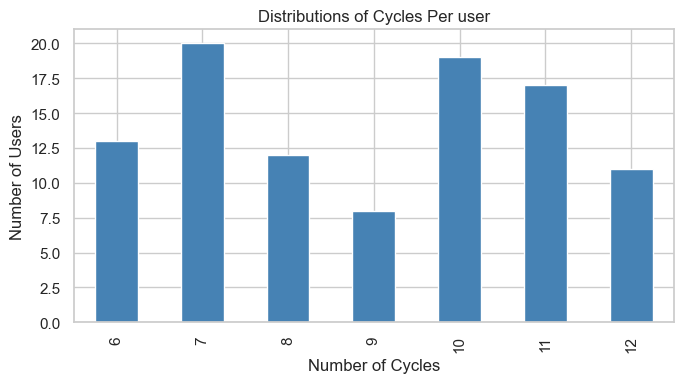

In [130]:
# cell 5 - unique users
#   dataset is longitudinal -> multiple rows per user

n_users = df[config.USER_ID_COL].nunique()
n_rows  = len(df)
cycles_per_user = df.groupby(config.USER_ID_COL).size()

print(f"Unique users:       {n_users}")
print(f"Total rows:         {n_rows}")
print(f"Avg cycles/user:    {cycles_per_user.min()}")
print(f"Max cycles/user     {cycles_per_user.max()}")

# distribution of cycles per user
plt.figure(figsize=(7, 4))
cycles_per_user.value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Distributions of Cycles Per user")
plt.xlabel("Number of Cycles")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / "eda_cycles_per_user.png", dpi=150)
plt.show()


=== Target: Cycle Length (days) ===
count    895.00
mean      37.37
std        7.47
min       25.00
25%       31.00
50%       37.00
75%       43.00
max       50.00
Name: Cycle Length, dtype: float64


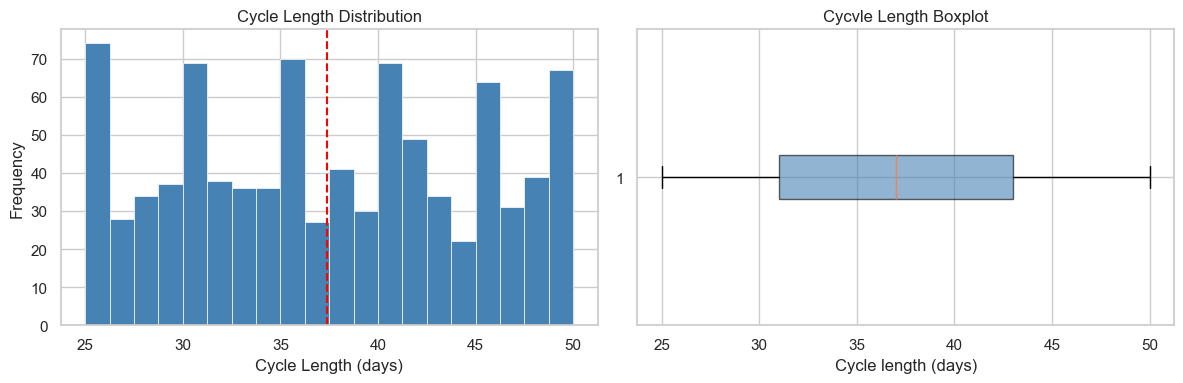

In [131]:
# cell 6 - target distribution visuualization
#   - normally distributed? -> good for linear regression
#   - any outliers?

print("=== Target: Cycle Length (days) ===")
print(df[config.TARGET_COL].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram -> shape
axes[0].hist(df[config.TARGET_COL], bins=20, color="steelblue",
            edgecolor="white", linewidth=0.5)
axes[0].axvline(df[config.TARGET_COL].mean(), color="red",
            linestyle="--", label=f"Mean: {df[config.TARGET_COL].mean():.1f}")
axes[0].set_title("Cycle Length Distribution")
axes[0].set_xlabel("Cycle Length (days)")
axes[0].set_ylabel("Frequency")
axes[0].legend

# boxplot -> outliers
axes[1].boxplot(df[config.TARGET_COL], vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Cycvle Length Boxplot")
axes[1].set_xlabel("Cycle length (days)")

plt.tight_layout()
plt.savefig(config.REPORTS_DIR / "eda_target_distribution.png", dpi=150)
plt.show()

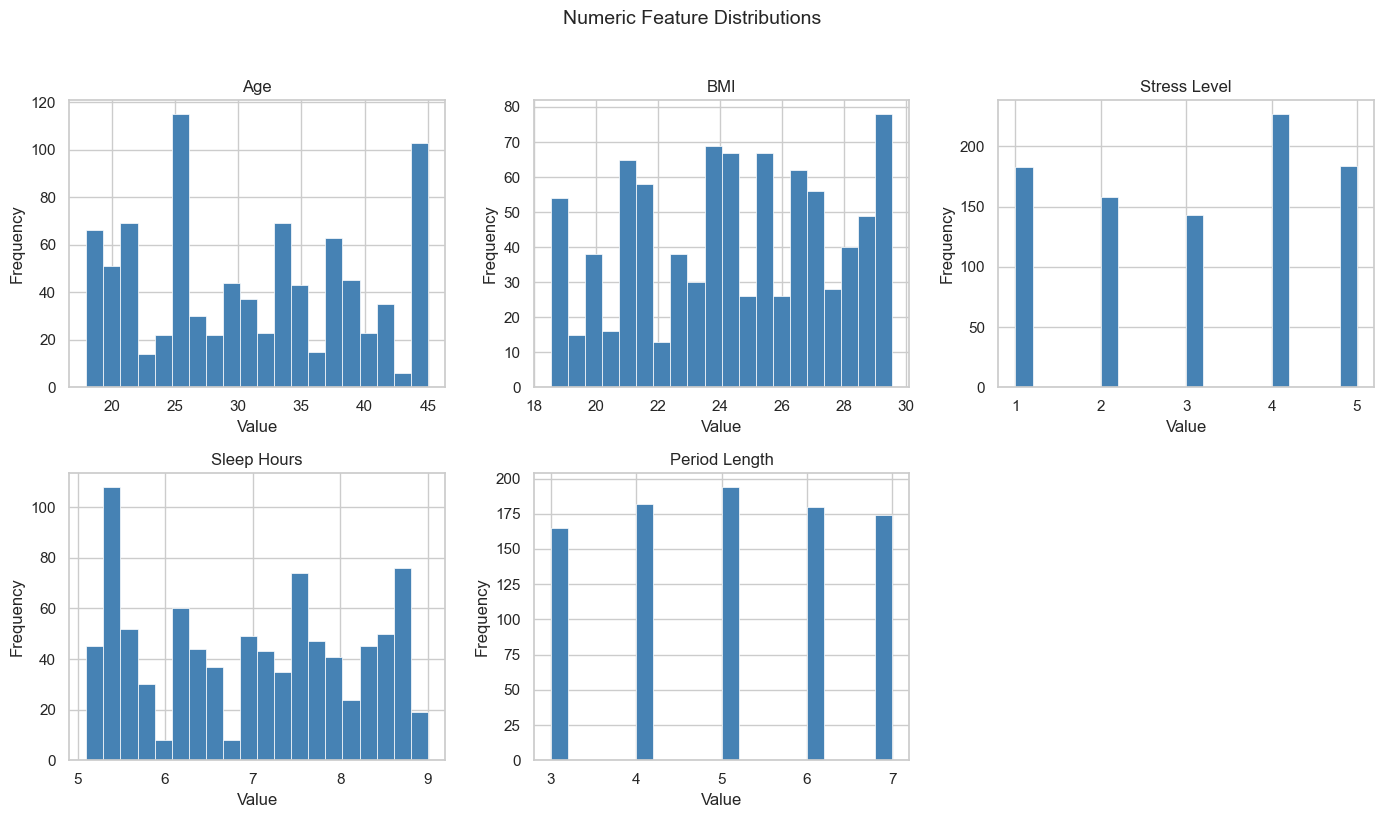

In [132]:
# Cell 7 — Numeric Feature Distributions
# Visualize all numeric features at once.


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(config.NUMERIC_COLS):
    axes[i].hist(df[col], bins=20, color="steelblue",
                 edgecolor="white", linewidth=0.5)
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# hide unused subplot if odd number of features
if len(config.NUMERIC_COLS) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle("Numeric Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / "eda_numeric_distributions.png", dpi=150)
plt.show()

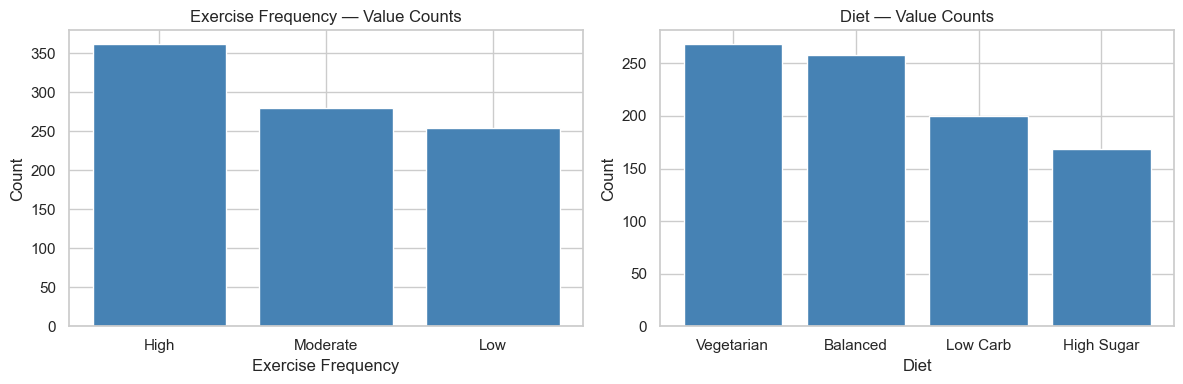


Exercise Frequency:
Exercise Frequency
High        361
Moderate    280
Low         254
Name: count, dtype: int64

Diet:
Diet
Vegetarian    268
Balanced      258
Low Carb      200
High Sugar    169
Name: count, dtype: int64


In [133]:
# Cell 8 — Categorical Feature Distributions
# Check class balance in categorical features.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(config.CATEGORICAL_COLS):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"{col} — Value Counts")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.savefig(config.REPORTS_DIR / "eda_categorical_distributions.png", dpi=150)
plt.show()

# print exact counts
for col in config.CATEGORICAL_COLS:
    print(f"\n{col}:\n{df[col].value_counts()}")

Correlation with Cycle Length:
Cycle Length     1.000
Sleep Hours      0.045
BMI              0.031
Stress Level     0.005
Period Length   -0.000
Age             -0.029
Name: Cycle Length, dtype: float64


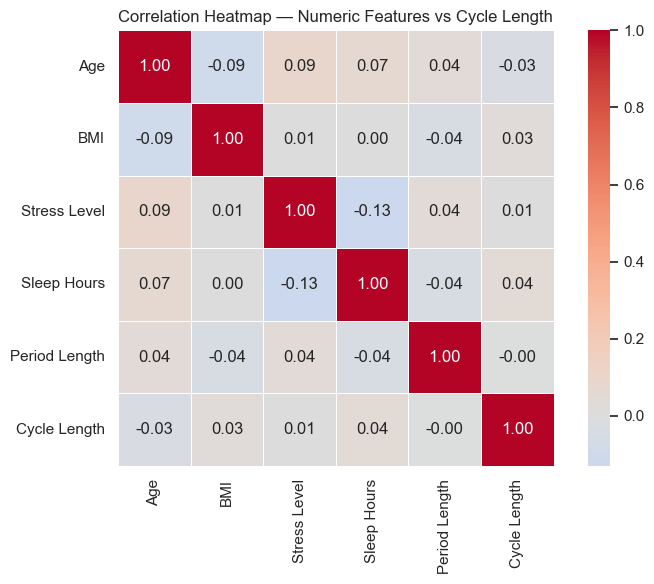

In [134]:
# Cell 9 
# Heat signal map -> shows what features have the most predictive signal

numeric_df = df[config.NUMERIC_COLS + [config.TARGET_COL]]
corr_matrix = numeric_df.corr().round(3)

print("Correlation with Cycle Length:")
print(corr_matrix[config.TARGET_COL].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Numeric Features vs Cycle Length")
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / "eda_correlation_heatmap.png", dpi=150)
plt.show()

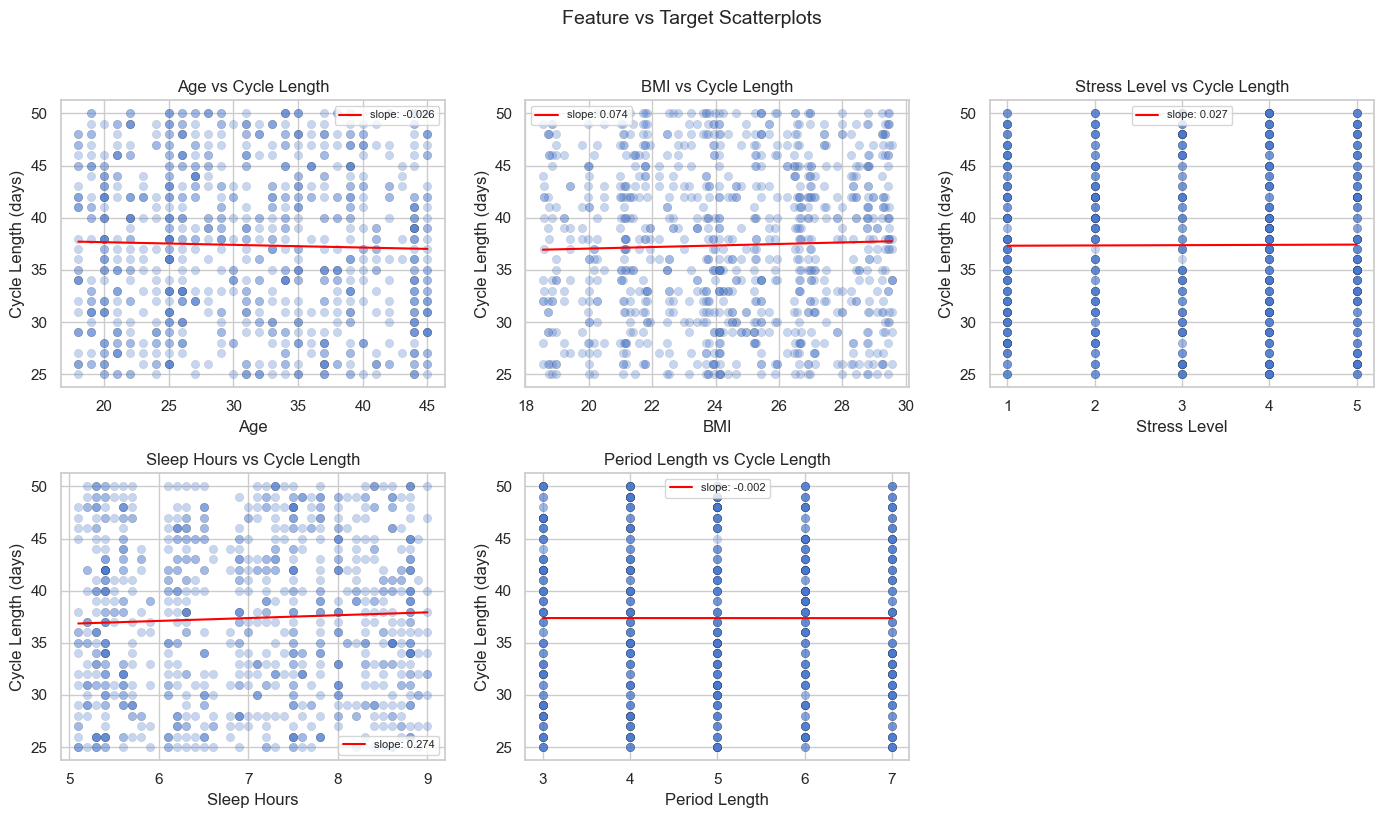

In [135]:
# cell 10 - Scatterplots: each feature vs target

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(config.NUMERIC_COLS):
    axes[i].scatter(df[col], df[config.TARGET_COL],
                    alpha=0.3, edgecolors="k", linewidths=0.2)
    
    # add linear trend line
    m, b = np.polyfit(df[col], df[config.TARGET_COL], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="red",
                 linewidth=1.5, label=f"slope: {m:.3f}")
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Cycle Length (days)")
    axes[i].set_title(f"{col} vs Cycle Length")
    axes[i].legend(fontsize=8)

if len(config.NUMERIC_COLS) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle("Feature vs Target Scatterplots", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / "eda_scatterplots.png", dpi=150)
plt.show()


/var/folders/6b/pjn3nqqn0qx8_vxmxqyyphxc0000gn/T/ipykernel_54631/1321902910.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_cat, labels=categories, patch_artist=True,
/var/folders/6b/pjn3nqqn0qx8_vxmxqyyphxc0000gn/T/ipykernel_54631/1321902910.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_cat, labels=categories, patch_artist=True,


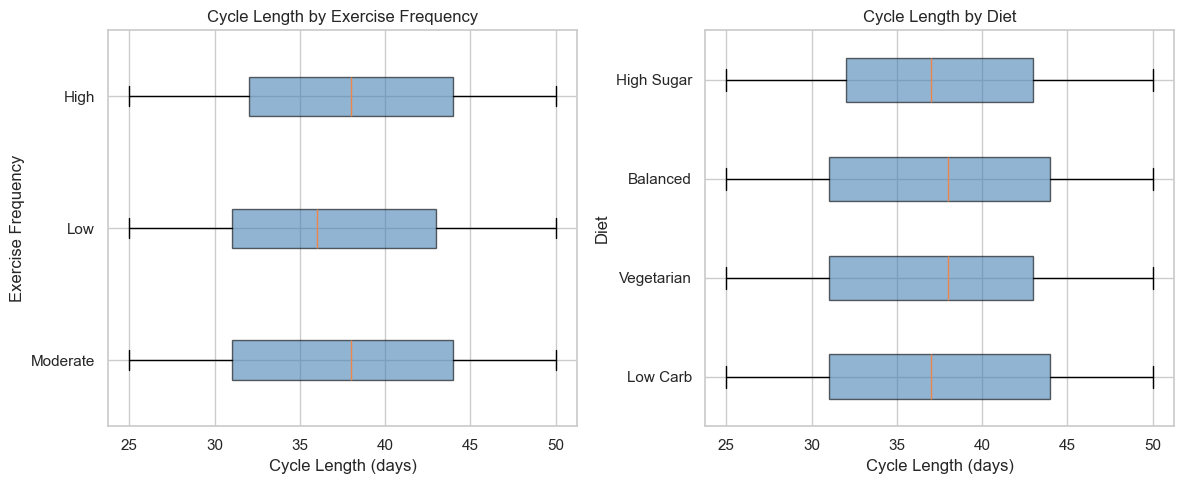

In [136]:
# cell 11 - cycle length by categorical feature

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(config.CATEGORICAL_COLS):
    categories = df[col].unique()
    data_by_cat = [df[df[col] == cat][config.TARGET_COL].values
                   for cat in categories]

    axes[i].boxplot(data_by_cat, labels=categories, patch_artist=True,
                    vert=False,    # ← makes it horizontal
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(f"Cycle Length by {col}")
    axes[i].set_xlabel("Cycle Length (days)")   # ← now on x axis
    axes[i].set_ylabel(col)                     # ← categories on y axis
    axes[i].tick_params(axis="y", rotation=0)   # ← y axis labels now

plt.tight_layout()
plt.savefig(config.REPORTS_DIR / "eda_categorical_boxplots.png", dpi=150)
plt.show()

In [137]:
# Cell 12 — EDA Summary

print("""
=== EDA SUMMARY ===

Dataset
-------
- 895 rows, 100 unique users, ~9 cycles per user
- Longitudinal structure → used GroupShuffleSplit to prevent leakage
- Zero null values → no imputation required

Target: Cycle Length
--------------------
- Range: 25–50 days
- Mean: ~37.4 days, Std: ~7.5 days
- Roughly symmetric distribution → suitable for linear regression

Numeric Features
----------------
- All correlations with cycle length are weak (|r| < 0.1)
- No single numeric feature shows a strong linear relationship
- Scatterplots confirm no hidden non-linear patterns

Categorical Features
--------------------
- Exercise Frequency and Diet are reasonably balanced across categories
- Boxplots show heavy overlap between categories → weak separation

Conclusion
----------
- Features carry very limited predictive signal for cycle length
- A linear model is unlikely to outperform a mean baseline
- This finding is consistent with reproductive health literature:
  cycle length variation is largely driven by individual physiology
  and hormonal patterns not captured in this dataset
""")


=== EDA SUMMARY ===

Dataset
-------
- 895 rows, 100 unique users, ~9 cycles per user
- Longitudinal structure → used GroupShuffleSplit to prevent leakage
- Zero null values → no imputation required

Target: Cycle Length
--------------------
- Range: 25–50 days
- Mean: ~37.4 days, Std: ~7.5 days
- Roughly symmetric distribution → suitable for linear regression

Numeric Features
----------------
- All correlations with cycle length are weak (|r| < 0.1)
- No single numeric feature shows a strong linear relationship
- Scatterplots confirm no hidden non-linear patterns

Categorical Features
--------------------
- Exercise Frequency and Diet are reasonably balanced across categories
- Boxplots show heavy overlap between categories → weak separation

Conclusion
----------
- Features carry very limited predictive signal for cycle length
- A linear model is unlikely to outperform a mean baseline
- This finding is consistent with reproductive health literature:
  cycle length variation is larg